In [1]:
import os
import zipfile
import pyarrow.parquet as pq
import pandas as pd

folder = r"F:\sanazi\python\data science\code\tamrin\proje\Tennis Schema\Tennis Schema\tennis_data"

data = {}

for file in os.listdir(folder): 
    if file.endswith(".zip"): 

        zip_path = os.path.join(folder, file) 

        with zipfile.ZipFile(zip_path) as z: 
            for parquet_file in z.namelist():

                if parquet_file.endswith(".parquet"): 

                    with z.open(parquet_file) as f:
                        df = pq.read_table(f).to_pandas()
                    table_name =os.path.basename(os.path.dirname(parquet_file))[4:-8] + os.path.basename(parquet_file)[:-17] 

                    if table_name not in data:
                        data[table_name] = [] 
                    data[table_name].append(df) 


for table_name in data:
    data[table_name] = pd.concat(data[table_name], ignore_index=True)

print(data.keys())

C:\Users\sepehr\AppData\Local\Temp\ipykernel_3068\1606281692.py:30: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  data[table_name] = pd.concat(data[table_name], ignore_index=True)


dict_keys(['matchaway_team', 'matchaway_team_score', 'matchevent', 'matchhome_team', 'matchhome_team_score', 'matchround', 'matchseason', 'matchtime', 'matchtournament', 'matchvenue', 'oddsodds', 'point_by_pointpbp', 'statisticsstatistics', 'tennis_powerpower', 'votesvotes'])


In [4]:
statistics = data["statisticsstatistics"]

print(statistics.columns)
print(statistics["statistic_name"].unique())

Index(['match_id', 'period', 'statistic_category_name', 'statistic_name',
       'home_stat', 'away_stat', 'compare_code', 'statistic_type',
       'value_type', 'home_value', 'away_value', 'home_total', 'away_total'],
      dtype='object')
['aces' 'double_faults' 'first_serve' 'second_serve' 'first_serve_points'
 'second_serve_points' 'service_games_played' 'break_points_saved' 'total'
 'service_points_won' 'receiver_points_won' 'max_points_in_a_row'
 'total_won' 'service_games_won' 'max_games_in_a_row'
 'first_serve_return_points' 'second_serve_return_points'
 'return_games_played' 'break_points_converted' 'tiebreaks']


In [8]:
print(statistics["period"].unique())

['ALL' '1ST' '2ND' '3RD']


In [23]:
print(list(data.keys()))

['matchaway_team', 'matchaway_team_score', 'matchevent', 'matchhome_team', 'matchhome_team_score', 'matchround', 'matchseason', 'matchtime', 'matchtournament', 'matchvenue', 'oddsodds', 'point_by_pointpbp', 'statisticsstatistics', 'tennis_powerpower', 'votesvotes']


In [24]:
tournament = data["matchtournament"]
event = data["matchevent"]

print("matchtournament columns:")
print(tournament.columns.tolist())
print(tournament.head())

print("\nmatchevent columns:")
print(event.columns.tolist())
print(event.head())


matchtournament columns:
['match_id', 'tournament_id', 'tournament_name', 'tournament_slug', 'tournament_unique_id', 'tournament_category_name', 'tournament_category_slug', 'user_count', 'ground_type', 'tennis_points', 'has_event_player_statistics', 'crowd_sourcing_enabled', 'has_performance_graph_feature', 'display_inverse_home_away_teams', 'priority', 'competition_type']
   match_id  tournament_id      tournament_name     tournament_slug  \
0  11974053          70826           Qualifiers          qualifiers   
1  11974066          70826           Qualifiers          qualifiers   
2  11998445         126168  Montpellier, France  montpellier-france   
3  11998446         126168  Montpellier, France  montpellier-france   
4  11998447         126168  Montpellier, France  montpellier-france   

  tournament_unique_id tournament_category_name tournament_category_slug  \
0                 None                Davis Cup                davis-cup   
1                 None                Davis C

In [25]:
import pandas as pd


double_faults = statistics[statistics["statistic_name"] == "double_faults"].copy()
double_faults = double_faults[double_faults["period"] == "ALL"]

double_faults["home_value"] = pd.to_numeric(double_faults["home_value"], errors="coerce")
double_faults["away_value"] = pd.to_numeric(double_faults["away_value"], errors="coerce")
double_faults["total_double_faults"] = double_faults["home_value"] + double_faults["away_value"]


tournament = data["matchtournament"]


print(tournament["tournament_category_name"].unique())

def detect_gender(cat):
    cat = str(cat).upper()
    if cat == "ATP":
        return "Men"
    elif cat == "WTA":
        return "Women"
    else:
        return None 

tournament["gender"] = tournament["tournament_category_name"].apply(detect_gender)


merged = double_faults.merge(
    tournament[["match_id", "gender"]],
    on="match_id",
    how="left"
)


merged = merged[merged["gender"].notna()]


result = merged.groupby("gender")["total_double_faults"].agg(["mean", "count", "std"])
print(result)


['Davis Cup' 'ATP' 'Challenger' 'WTA' 'ITF Women' 'ITF Men'
 'Challenger Women']
            mean  count       std
gender                           
Men     4.815175   3295  3.086215
Women   6.730471   2842  4.276173


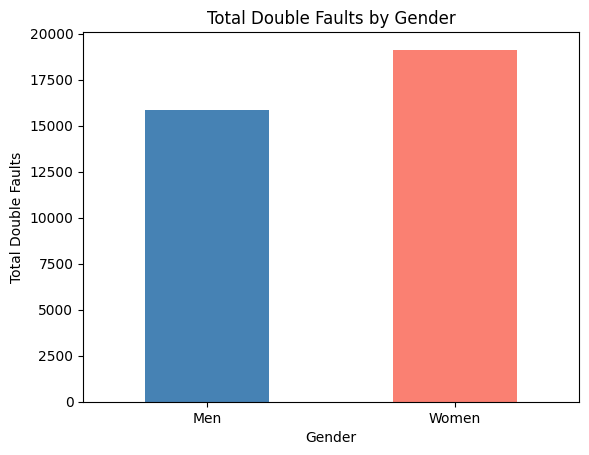

In [27]:
import matplotlib.pyplot as plt

total_df = merged.groupby("gender")["total_double_faults"].sum()

total_df.plot(kind="bar", color=["steelblue", "salmon"])

plt.title("Total Double Faults by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Double Faults")
plt.xticks(rotation=0)
plt.show()